# Counterfeit detection


The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository.  You have already used this set but this time I have removed  the first column. The set  `banknote_authentication.csv` can be found in the `data`  directory.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, auc, confusion_matrix, roc_curve, roc_auc_score
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split


In [2]:
data = pd.read_csv('data/banknote_authentication.csv')
data.head()


,a1,a2,a3,counterfeit
0,12.3784,0.70403,-7.58360,0
1,8.1881,-3.13380,-2.52760,0
2,-10.8679,9.49260,-1.41160,1
3,-8.7903,7.97350,-0.45475,1
4,-5.5167,10.93900,-0.40820,1


In [3]:
X = data.drop(columns='counterfeit')
y = data['counterfeit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Train size: {len(X_train)}, test size: {len(X_test)}')
print('Positive class share in train:', round(y_train.mean(), 3))


Train size: 767, test size: 330
Positive class share in train: 0.445


## Problem


### A.

Perform the Quadratic Discriminant Analysis on this set. Calculate the confusion matrix, AUC score and plot the ROC curve.


In [4]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

qda_test_proba = qda.predict_proba(X_test)[:, 1]
qda_test_pred = (qda_test_proba >= 0.5).astype(int)

qda_cm = confusion_matrix(y_test, qda_test_pred)
qda_auc = roc_auc_score(y_test, qda_test_proba)

print('Confusion matrix:')
print(qda_cm)
print(f'AUC: {qda_auc:.4f}')


Confusion matrix:
[[144  39]
 [ 24 123]]
AUC: 0.8807


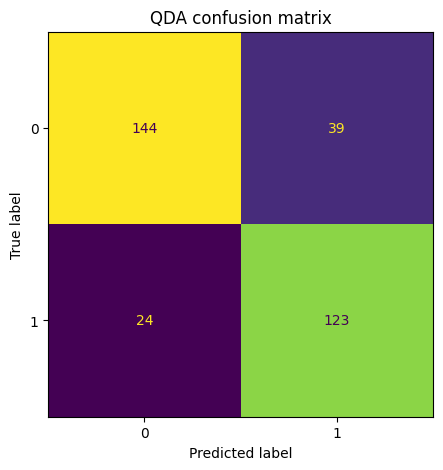

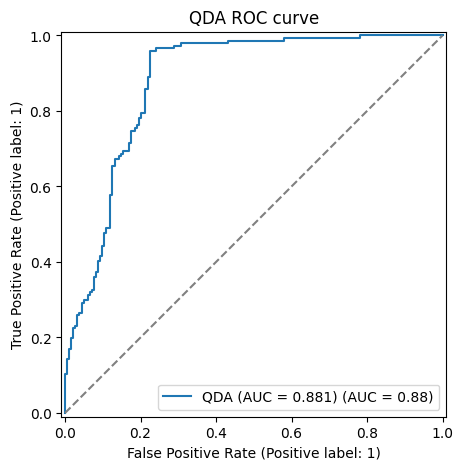

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(qda_cm, display_labels=qda.classes_).plot(ax=ax, colorbar=False)
ax.set_title('QDA confusion matrix')
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, qda_test_proba, ax=ax, name=f'QDA (AUC = {qda_auc:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_title('QDA ROC curve')
plt.show()


### B.

Perform Gaussian Mixture Discriminant Analysis on this set as described in the `gaussian_mixture_model_EM_algorithm` notebook. Use two components for positives and two components for negatives. Calculate the confusion matrix, AUC score and plot the ROC curve.


In [6]:
gm0 = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gm1 = GaussianMixture(n_components=2, covariance_type='full', random_state=42)

gm0.fit(X_train[y_train == 0])
gm1.fit(X_train[y_train == 1])

pi1 = y_train.mean()
pi0 = 1 - pi1

print(f'Class prior P(y=0): {pi0:.3f}')
print(f'Class prior P(y=1): {pi1:.3f}')


Class prior P(y=0): 0.555
Class prior P(y=1): 0.445


In [ ]:
def make_predict_proba(gm0, gm1, pi1):
    pi0 = 1 - pi1

    def predict_proba(X):
        p0 = pi0 * np.exp(gm0.score_samples(X))
        p1 = pi1 * np.exp(gm1.score_samples(X))
        return p1 / (p0 + p1)

    return predict_proba

mgda = make_predict_proba(gm0, gm1, pi1=pi1)
mgda_test_proba = mgda(X_test)
mgda_test_pred = (mgda_test_proba >= 0.5).astype(int)

mgda_cm = confusion_matrix(y_test, mgda_test_pred)
mgda_auc = roc_auc_score(y_test, mgda_test_proba)

print('Confusion matrix:')
print(mgda_cm)
print(f'AUC: {mgda_auc:.4f}')


Confusion matrix:
[[174   9]
 [ 23 124]]
AUC: 0.9655


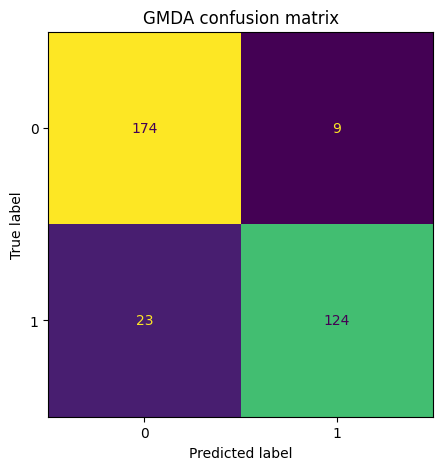

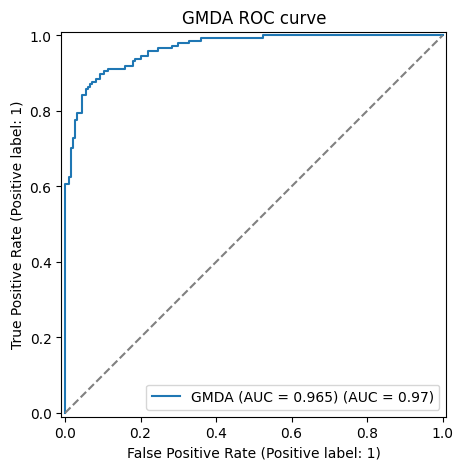

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(mgda_cm, display_labels=[0, 1]).plot(ax=ax, colorbar=False)
ax.set_title('GMDA confusion matrix')
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, mgda_test_proba, ax=ax, name=f'GMDA (AUC = {mgda_auc:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_title('GMDA ROC curve')
plt.show()


In [9]:
mgda_test_proba[:10]


array([0.99135138, 0.33283406, 0.99996682, 0.27276662, 0.00789972,
       0.21550932, 0.99986894, 0.92499276, 0.99477164, 0.08674677])